### variables:
    - Relationship_Type (Father/Son 0.98, Brother 0,95, Cousin 0.70, Unrelated 0.01)
    - Mutation_Count (0 exact match, 1 small mutation, 2+ more divergence)
        - Even related people can differ slightly because because Y-STR markers mutate over generations
    - Sample_Quality
        - represents how reliable the crime-scene DNA sample is
    - Population_Frequency (rarity of the haplotype)
        - how common the Y-str profile is in the population (rare/medium/common)
        - important because common profiles give weaker evidence
    - Y_STR_Match
        - represents similarity between the sample and a profile from the database (full/partial/none)
    - Database_Hit
        - Whether the database search produced a candidate match (yes/no)
    - Evidence_Strength (Likelihood_Ratio: forensic evidence weight)
    
    - Related_Classification / Observed match?
    
    - Posterior_Related (final prob)
    

In [ ]:
RelationshipType -> mutation_count -> Y_STR_Match <- Sample_Quality

Y_STR_MATCH -> Likelihood_Ratio <- population_rarity

Likelihood_Ratio -> Database_Hit -> Related_classification

In [2]:
import pyagrum as gum
bn = gum.BayesNet("Forensic DNA")
print(bn)

BN{nodes: 0, arcs: 0, domainSize: 1, dim: 0, mem: 0o}


In [3]:
bn.add(gum.LabelizedVariable("rel", "Relation", 2))
bn.add(gum.LabelizedVariable("mut_count", "Mutation Count", 2))
bn.add(gum.LabelizedVariable("sam_ql", "Sample Quality", 2))
bn.add(gum.LabelizedVariable("pop_freq", "Population Frequency", 2))
bn.add(gum.LabelizedVariable("y_match", "Y_STR Match", 2))
bn.add(gum.LabelizedVariable("db_hit", "Database Hit", 2))
bn.add(gum.LabelizedVariable("ev_str", "Evidence Strength", 2))

6

In [4]:
print(bn)

BN{nodes: 7, arcs: 0, domainSize: 128, dim: 7, mem: 112o}


In [5]:
bn.addArc("rel_type", "mut_count")

In [6]:
import pyagrum.lib.notebook as gnb

In [7]:
bn

(pyagrum.BayesNet@00000295844D0AF0) BN{nodes: 7, arcs: 1, domainSize: 128, dim: 8, mem: 128o}

In [ ]:
# RelationType
#       ↓
# MutationCount
#       ↓
# Observed Y-STR Match

# Database Hit ────┐
#                  ├→ Evidence Strength
# PopulationFreq ──┤
#                  │
# Observed Match ──┘

# A simple Bayesian network
Paternal Relationship ──► True Y-Profile Match ──► Observed Database Match
                                  ▲                         ▲
                                  │                         │
                         Haplotype Frequency        Sample Quality

Paternal Relationship ──► Investigative Leads

Other Evidence ─────────► Evidence Strength

Observed Database Match ─► Evidence Strength

Investigative Leads ─────► Evidence Strength

## Variables
### Paternal Relationship (hidden)
The true relationship between the unknown offender and the database individual.
This is the key variable.

### Haplotype Frequency
How common the Y-STR profile is in the relevant population.

States:
- Rare
- Moderate
- Common

A match to a rare haplotype is stronger evidence of a paternal relationship than a match to a common one.

### True Y-Profile Match (hidden)
Whether the offender truly shares the same Y profile as the database individual.

### Sample Quality
States:
- High
- Medium
- Low

This affects the reliability of the observed result.

### Observed Database Match
States:
- Match
- No match
- Inconclusive

This is what the laboratory reports.

### Investigative Leads
Information obtained after identifying the paternal lineage. (Information obtained after identifying a potential paternal lineage that helps narrow the pool of candidate individuals.)

Examples:
Family tree reconstructed
Geographic proximity
Age compatibility
Number of candidate males

States could be:
- Strong leads
- Weak leads
- No leads

### Other Evidence
Traditional evidence independent of the Y-STR result:
- CCTV
- Witnesses
- Phone records
- Fingerprints

### Evidence Strength
Your final outcome variable:
- Weak
- Moderate
- Strong

or:
Posterior probability that the offender belongs to the paternal lineage
Why this network works

## The causal story is:
The offender has some relationship to a man in the database.
That relationship influences whether they share a Y profile.
Sample quality influences whether the laboratory observes a match.
Investigators use the match to identify a paternal lineage.
Other evidence determines whether the lineage actually contains the offender.

The important insight is:
Y-STR evidence narrows the search to a family, not to an individual.

### Example reasoning
Suppose investigators observe:
- A high-quality sample
- A rare Y haplotype
- A database match
- The matched individual's paternal relatives live near the crime scene

The network should increase the probability that:
The offender is a paternal relative of the matched individual.
However, it should not automatically assign high probability to the matched individual being the offender.
That distinction is exactly what makes Y-STR evidence an interesting application of Bayesian reasoning.
Once you have this structure, the next step is to define the conditional probabilities—for example:

P(True Y-Profile Match ∣Paternal Relationship)
P(Observed Database Match ∣ True Y-Profile Match, Sample Quality)
P(Investigative Leads ∣ Paternal Relationship)

Those tables can initially be based on expert estimates rather than real genetic data.

# Network

In [27]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb

bn = gum.BayesNet("Y_STR_Familial_Search")
# ------------------------------------------------------------------
# Variables
# ------------------------------------------------------------------

relationship = bn.add(
    gum.LabelizedVariable(
        "Relationship",
        "Relationship between offender and database match",
        [
            "related",
            "unrelated"
        ]
    )
)

hap_freq = bn.add(
    gum.LabelizedVariable(
        "HaplotypeFrequency",
        "Frequency of the Y-STR profile",
        ["rare", "common"]
    )
)

observed_match = bn.add(
    gum.LabelizedVariable(
        "ObservedMatch",
        "Laboratory result",
        ["match", "no_match"]
    )
)

genetic_evidence = bn.add(
    gum.LabelizedVariable(
        "GeneticEvidence",
        "Genetic Evidence Strength",
        ["strong", "weak"]
    )
)

investigative_leads = bn.add(
    gum.LabelizedVariable(
        "InvestigativeLeads",
        "Strength of genealogical investigation",
        ["useful", "not_useful"]
    )
)

other_evidence = bn.add(
    gum.LabelizedVariable(
        "OtherEvidence",
        "Strength of non-DNA evidence",
        ["supportive", "neutral"]
    )
)

evidence_strength = bn.add(
    gum.LabelizedVariable(
        "EvidenceStrength",
        "Overall evidence that offender belongs to the lineage",
        ["strong", "weak"]
    )
)

# ------------------------------------------------------------------
# Arcs
# ------------------------------------------------------------------

bn.addArc("Relationship", "ObservedMatch")
bn.addArc("HaplotypeFrequency", "GeneticEvidence")

bn.addArc("ObservedMatch", "GeneticEvidence")

bn.addArc("Relationship", "InvestigativeLeads")

bn.addArc("GeneticEvidence", "EvidenceStrength")
bn.addArc("InvestigativeLeads", "EvidenceStrength")
bn.addArc("OtherEvidence", "EvidenceStrength")

bn

(pyagrum.BayesNet@000002601E2DD6C0) BN{nodes: 7, arcs: 7, domainSize: 128, dim: 19, mem: 304o}

# Priors

In [34]:
# ------------------------------------------------------------------
# CPTs
# ------------------------------------------------------------------

# Relationship {related, unrelated}
bn.cpt("Relationship").fillWith([0.01, 0.99])

# Haplotype {rare, common}
bn.cpt("HaplotypeFrequency").fillWith([0.1, 0.9])

# Observed match {match, no_match}
bn.cpt("ObservedMatch")[{
    "Relationship": "related",
}] = [0.99, 0.01]

bn.cpt("ObservedMatch")[{
    "Relationship": "unrelated",
}] = [0.005, 0.995]

# Investigative leads {useful, not useful}
bn.cpt("InvestigativeLeads")[{
    "Relationship": "related"}] = [0.85, 0.15]

bn.cpt("InvestigativeLeads")[{
    "Relationship": "unrelated"}] = [0.05, 0.95]

# Other evidence {suppoertive, neutral}
bn.cpt("OtherEvidence").fillWith([0.2, 0.8])

# Genetic evidence {strong, weak}
bn.cpt("GeneticEvidence")[{
    "ObservedMatch": "match",
    "HaplotypeFrequency": "rare"
}] = [0.99, 0.1]

bn.cpt("GeneticEvidence")[{
    "ObservedMatch": "match",
    "HaplotypeFrequency": "common"
}] = [0.75, 0.25]

bn.cpt("GeneticEvidence")[{
    "ObservedMatch": "no_match",
    "HaplotypeFrequency": "rare"
}] = [0.1, .9]

bn.cpt("GeneticEvidence")[{
    "ObservedMatch": "no_match",
    "HaplotypeFrequency": "common"
}] = [0.01, 0.99]

# Overall evidence strength {strong, weak}
bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "strong",
    "InvestigativeLeads": "useful",
    "OtherEvidence": "supportive"
}] = [0.95, 0.05]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "strong",
    "InvestigativeLeads": "useful",
    "OtherEvidence": "neutral"
}] = [0.8, 0.2]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "strong",
    "InvestigativeLeads": "not_useful",
    "OtherEvidence": "supportive"
}] = [0.85, 0.15]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "strong",
    "InvestigativeLeads": "not_useful",
    "OtherEvidence": "neutral"
}] = [0.7, 0.3]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "weak",
    "InvestigativeLeads": "useful",
    "OtherEvidence": "supportive"
}] = [0.3, 0.7]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "weak",
    "InvestigativeLeads": "useful",
    "OtherEvidence": "neutral"
}] = [0.25, 0.75]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "weak",
    "InvestigativeLeads": "not_useful",
    "OtherEvidence": "supportive"
}] = [0.2, 0.8]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "weak",
    "InvestigativeLeads": "not_useful",
    "OtherEvidence": "neutral"
}] = [0.1, 0.9]

print(bn)

BN{nodes: 7, arcs: 7, domainSize: 128, dim: 19, mem: 304o}


In [35]:
bn

(pyagrum.BayesNet@000002601E2DD6C0) BN{nodes: 7, arcs: 7, domainSize: 128, dim: 19, mem: 304o}

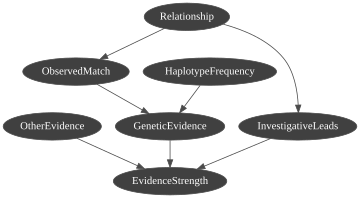

In [36]:
gnb.showBN(bn)

In [37]:
import pyagrum.lib.image as gumimage
gumimage.export(bn, "y_str_bn.png")

In [38]:
row = []
for node in bn.names():
    row.append(bn.cpt(node))

gnb.flow.row(*row)

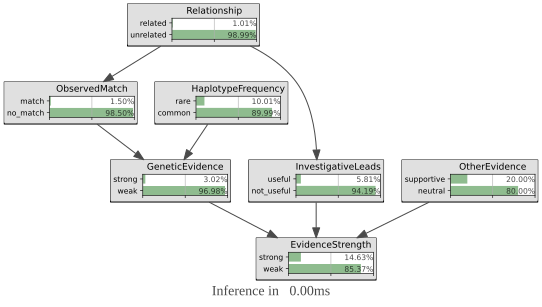

In [39]:
gnb.showInference(bn, evs={})

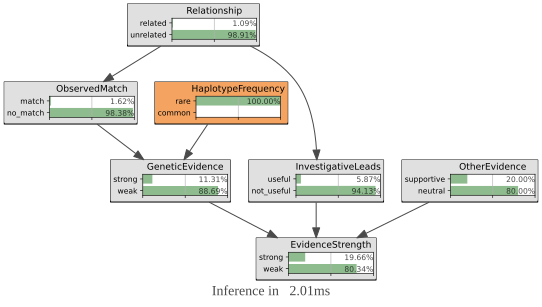

In [40]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare"})

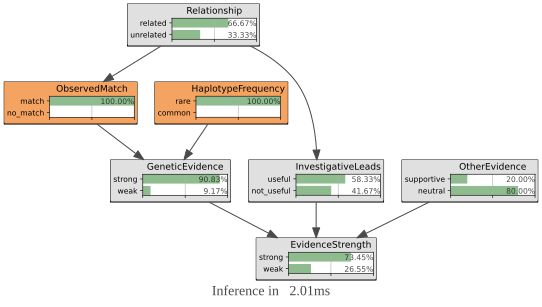

In [41]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"match"})

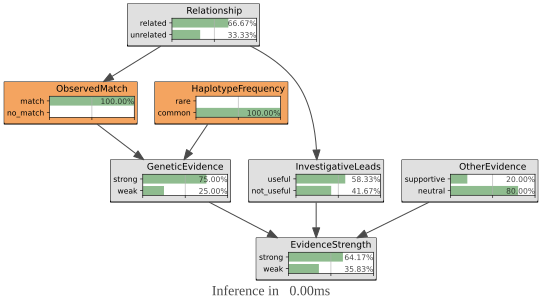

In [42]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "common", "ObservedMatch":"match"})

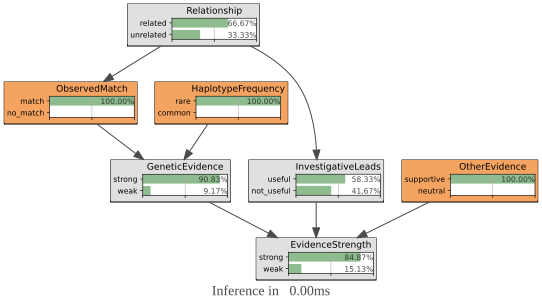

In [43]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"match", "OtherEvidence":"supportive"})

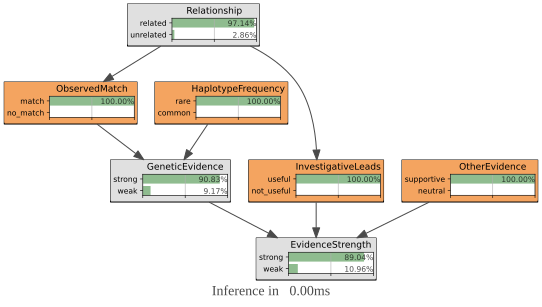

In [44]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"match", "OtherEvidence":"supportive", "InvestigativeLeads": "useful"})

### Familial DNA searching
- Finding Criminals Through DNA of Their Relatives: https://charlesbrenner.com/downloads/papers/Finding%20Criminals%20SOM.pdf (10 pages)
- The Rarity of DNA Profiles: https://pmc.ncbi.nlm.nih.gov/articles/PMC2585748/pdf/nihms47987.pdf (16 pages)


### Y-chromosome profile (to verify the idea) intro+conclusions
- How Convincing Is a Matching Y-Chromosome Profile? https://journals.plos.org/plosgenetics/article/file?id=10.1371/journal.pgen.1007028&type=printable (16)
- Y-Profile Evidence: Close Paternal Relatives and Mixtures https://www.biorxiv.org/content/biorxiv/early/2018/07/20/373423.full.pdf (19)

### Bayesian networks in forensic science
- Bayesian Networks for Evaluating Forensic DNA Profiling Evidence: A Review and Guide to Literature: https://madoc.univ-nantes.fr/pluginfile.php/342373/mod_resource/content/0/ECD/forensicDNA.pdf (11 pages)
  
### Investigative genetic genealogy
Using Genetic Genealogy Databases in Missing Persons and Violent Crime Investigations: https://discovery.ucl.ac.uk/id/eprint/10077630/1/Kennett_2019_AAM_Using%20genetic%20genealogy%20databases%20FSI%20preprint.pdf

### Y-chromosomal kinship estimation
https://www.fsigeneticssup.com/article/S1875-1768%2822%2900066-X/pdf (3 pages)

Next steps:
- Play with the network
    - score outcomes to set priors for EvidenceStrength
    - Explore some hypotheses e.g. Sample quality is known or Haplotypefrequency or combinations of evidence
- Read some research to justify variables
    - Describe related work
    - Conclude the network and chosen parameters/priors
- add parameters + prior estimates
- reasoning examples with evidence
    - As a causal network? 
- Write introduction + justify network with sources
- Generate data
- Learn back the framework
- Describe why it does (not) work
- discussion/conclusions

# Generating Data

In [45]:
import pyagrum.lib.bn_vs_bn as bnvsbn

# generator
gen = gum.BNDatabaseGenerator(bn)

# generate 100 samples
gen.drawSamples(1000)

df = gen.to_pandas()

df.head()

,Relationship,HaplotypeFrequency,ObservedMatch,GeneticEvidence,InvestigativeLeads,OtherEvidence,EvidenceStrength
0,unrelated,common,no_match,weak,not_useful,neutral,weak
1,unrelated,common,no_match,weak,not_useful,neutral,weak
2,unrelated,common,no_match,weak,not_useful,neutral,weak
3,unrelated,common,no_match,weak,not_useful,neutral,weak
4,unrelated,common,no_match,weak,not_useful,neutral,weak


In [46]:
df.head(10)

,Relationship,HaplotypeFrequency,ObservedMatch,GeneticEvidence,InvestigativeLeads,OtherEvidence,EvidenceStrength
0,unrelated,common,no_match,weak,not_useful,neutral,weak
1,unrelated,common,no_match,weak,not_useful,neutral,weak
2,unrelated,common,no_match,weak,not_useful,neutral,weak
3,unrelated,common,no_match,weak,not_useful,neutral,weak
4,unrelated,common,no_match,weak,not_useful,neutral,weak
5,unrelated,common,no_match,weak,not_useful,neutral,strong
6,unrelated,common,no_match,weak,not_useful,neutral,weak
7,unrelated,common,no_match,weak,not_useful,neutral,weak
8,unrelated,common,no_match,weak,not_useful,neutral,weak
9,unrelated,common,no_match,weak,not_useful,neutral,weak


In [47]:
df[df["Relationship"] == "related"]

,Relationship,HaplotypeFrequency,ObservedMatch,GeneticEvidence,InvestigativeLeads,OtherEvidence,EvidenceStrength
73,related,common,match,weak,useful,neutral,weak
105,related,common,match,strong,useful,supportive,strong
119,related,common,match,strong,useful,neutral,strong
145,related,common,match,weak,useful,neutral,weak
159,related,common,match,strong,useful,neutral,strong
205,related,common,match,weak,useful,neutral,weak
239,related,common,match,strong,useful,supportive,strong
287,related,common,match,weak,useful,neutral,weak
543,related,common,match,strong,not_useful,neutral,strong
544,related,common,match,strong,not_useful,neutral,strong


In [21]:
df[df["Relationship"] == "unrelated"]

,Relationship,HaplotypeFrequency,SampleQuality,ObservedMatch,InvestigativeLeads,OtherEvidence,EvidenceStrength
0,unrelated,common,high,no_match,useful,neutral,weak
1,unrelated,common,high,no_match,not_useful,neutral,weak
2,unrelated,common,high,no_match,useful,supportive,strong
3,unrelated,common,high,no_match,not_useful,supportive,weak
4,unrelated,common,high,no_match,not_useful,neutral,weak
...,...,...,...,...,...,...,...
995,unrelated,common,high,no_match,not_useful,supportive,strong
996,unrelated,common,medium,no_match,not_useful,supportive,weak
997,unrelated,common,medium,no_match,not_useful,supportive,weak
998,unrelated,common,high,no_match,not_useful,neutral,weak


In [48]:
df[df["HaplotypeFrequency"] != "common"]

,Relationship,HaplotypeFrequency,ObservedMatch,GeneticEvidence,InvestigativeLeads,OtherEvidence,EvidenceStrength
13,unrelated,rare,no_match,weak,not_useful,neutral,weak
39,unrelated,rare,no_match,strong,not_useful,neutral,strong
44,unrelated,rare,no_match,weak,not_useful,supportive,strong
63,unrelated,rare,no_match,weak,not_useful,neutral,weak
78,unrelated,rare,no_match,weak,not_useful,supportive,weak
...,...,...,...,...,...,...,...
970,unrelated,rare,no_match,weak,not_useful,supportive,weak
981,unrelated,rare,no_match,weak,not_useful,neutral,weak
982,unrelated,rare,no_match,weak,not_useful,neutral,weak
994,unrelated,rare,no_match,weak,not_useful,neutral,weak


In [49]:
df[df["ObservedMatch"] == "match"]

,Relationship,HaplotypeFrequency,ObservedMatch,GeneticEvidence,InvestigativeLeads,OtherEvidence,EvidenceStrength
73,related,common,match,weak,useful,neutral,weak
84,unrelated,common,match,weak,not_useful,neutral,strong
105,related,common,match,strong,useful,supportive,strong
119,related,common,match,strong,useful,neutral,strong
129,unrelated,common,match,weak,not_useful,neutral,weak
145,related,common,match,weak,useful,neutral,weak
159,related,common,match,strong,useful,neutral,strong
205,related,common,match,weak,useful,neutral,weak
239,related,common,match,strong,useful,supportive,strong
287,related,common,match,weak,useful,neutral,weak


# Relearning the network

In [50]:
learner = gum.BNLearner(df, bn)
print(learner)

Filename       : C:\Users\jurge\AppData\Local\Temp\tmp3xpo8m4s.csv
Size           : (1000,7)
Variables      : Relationship[2], HaplotypeFrequency[2], ObservedMatch[2], GeneticEvidence[2], InvestigativeLeads[2], OtherEvidence[2], EvidenceStrength[2]
Induced types  : False
Missing values : False
Algorithm      : MIIC
Correction     : MDL
Prior          : -



In [52]:
learner.useLocalSearchWithTabuList()
print(learner)

Filename       : C:\Users\jurge\AppData\Local\Temp\tmp3xpo8m4s.csv
Size           : (1000,7)
Variables      : Relationship[2], HaplotypeFrequency[2], ObservedMatch[2], GeneticEvidence[2], InvestigativeLeads[2], OtherEvidence[2], EvidenceStrength[2]
Induced types  : False
Missing values : False
Algorithm      : Local Search with Tabu List
Tabu list size : 2
Score          : BDeu
Prior          : -



In [56]:
bn2=learner.learnBN()
bn2

(pyagrum.BayesNet@000002601E2DAE10) BN{nodes: 7, arcs: 8, domainSize: 128, dim: 17, mem: 272o}

In [54]:
bn2

(pyagrum.BayesNet@000002601E2DA840) BN{nodes: 7, arcs: 8, domainSize: 128, dim: 17, mem: 272o}

In [57]:
learner.useMIIC()
bn3 = learner.learnBN()
bn3

(pyagrum.BayesNet@000002601E2DEE00) BN{nodes: 7, arcs: 6, domainSize: 128, dim: 14, mem: 224o}

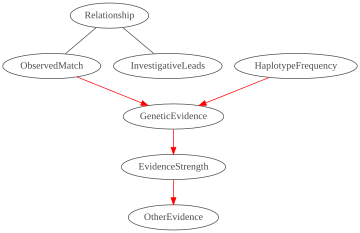

In [58]:
gemiic = learner.learnEssentialGraph()
gnb.show(gemiic)

In [59]:
learner.useGreedyHillClimbing()
bn3 = learner.learnBN()
bn3

(pyagrum.BayesNet@000002601E2DF3D0) BN{nodes: 7, arcs: 7, domainSize: 128, dim: 15, mem: 240o}

In [60]:
geHC = gum.EssentialGraph(bn3)

In [61]:
geHC

<pyagrum.pyagrum.EssentialGraph; proxy of <Swig Object of type 'gum::EssentialGraph *' at 0x0000026020B1D8F0> >

In [ ]:
def learnGraph(learner, method, samples):
    learner.method()
    new_bn = learner.learnBN()
    print(new_bn)

result for dataset size: 10000, and learning method: MIIC


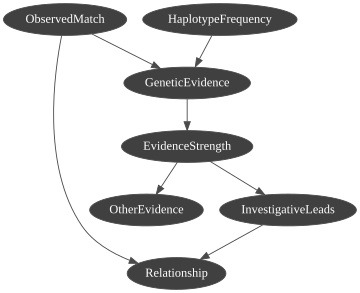

result for dataset size: 10000, and learning method: HC


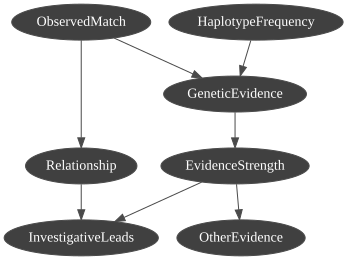

result for dataset size: 10000, and learning method: LS


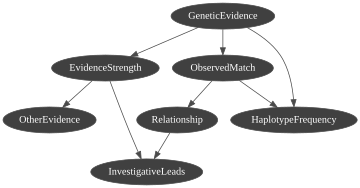

-----------------
-----------------
result for dataset size: 100000, and learning method: MIIC


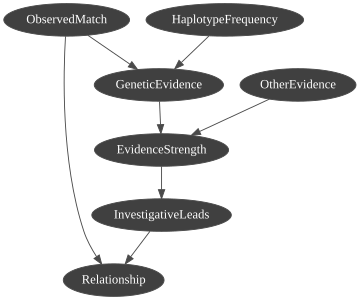

result for dataset size: 100000, and learning method: HC


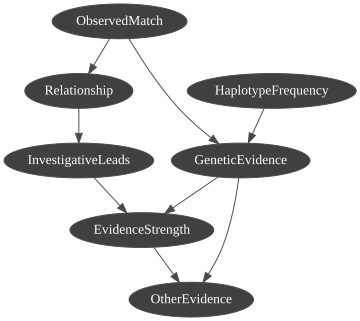

result for dataset size: 100000, and learning method: LS


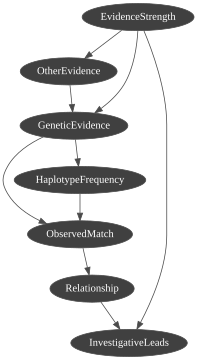

-----------------
-----------------


In [67]:
datasets_sizes = [10000, 100000]
methods = {
    "MIIC": lambda l: l.useMIIC(),
    "HC": lambda l: l.useGreedyHillClimbing(),
    "LS": lambda l: l.useLocalSearchWithTabuList()
}

for size in datasets_sizes:
    # generate data
    gen = gum.BNDatabaseGenerator(bn)
    gen.drawSamples(i)
    df = gen.to_pandas()

    # learn structure
    learner = gum.BNLearner(df, bn)
    for name, method in methods.items():
        method(learner)
        learned_bn = learner.learnBN()
        print(f'result for dataset size: {size}, and learning method: {name}')
        gnb.showBN(learned_bn)
    print('-----------------')
    print('-----------------')